In [1]:
%load_ext autoreload
%autoreload 2

import os
import mne
import tqdm
import numpy
import shutil
import joblib

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
src = "sleep/sleep-edf-database-expanded-1.0.0/sleep-cassette"
event_id = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4,
    "Sleep stage 4": 4,
    "Sleep stage R": 5
}
epoch_sec = 15.0

In [3]:
def process(subj_num, data_file, annotations_file):
    annot_train = mne.read_annotations(f"{src}/{annotations_file}")
    annot_train.crop(annot_train[1]["onset"] - 15 * 60, annot_train[-2]["onset"] + 15 * 60)

    raw_train = mne.io.read_raw_edf(f"{src}/{data_file}", preload=True, infer_types=True, verbose='error')
    raw_train.set_annotations(annot_train, verbose='error')
    raw_train.resample(50)

    events_train, _ = mne.events_from_annotations(raw_train, event_id=event_id, chunk_duration=epoch_sec, verbose='error')

    tmax = epoch_sec - 1.0 / raw_train.info["sfreq"]
    epochs_train = mne.Epochs(raw=raw_train, events=events_train, tmin=0.0, tmax=tmax, baseline=None, verbose='error')
    print(epochs_train.get_data().shape)

    event_types = epochs_train.events[:, 2]
    stage_edges = [0]
    for i in range(1, len(epochs_train)):
        if event_types[i - 1] != event_types[i]:
            stage_edges.append(i)
    stage_edges.append(len(epochs_train))
    stage_edges = numpy.array(stage_edges)

    dir = f"sleep-edf/Subj{subj_num}"
    os.makedirs(dir)
    shutil.copyfile(f"{src}/{data_file}", f"{dir}/eeg.edf")
    shutil.copyfile(f"{src}/{annotations_file}", f"{dir}/annotations.edf")
    raw_train.save(f"{dir}/data.fif")
    epochs_train.save(f"{dir}/epochs.fif")
    numpy.savetxt(f"{dir}/edges.txt", stage_edges.astype(int))

In [4]:
files = os.listdir(src)

tasks = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(process)(i, data_file, annotations_file)
    for i, (data_file, annotations_file) in tqdm.tqdm(list(enumerate(zip(files[::2], files[1::2]))))
)

 42%|████▏     | 64/153 [01:45<02:46,  1.87s/it]d:\Programs\Programming\Python\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 153/153 [04:34<00:00,  1.79s/it]


### Dump

In [ ]:
data_file = "SC4062E0-PSG.edf"
annotations_file = "SC4062EC-Hypnogram.edf"

raw_train = mne.io.read_raw_edf(f"{src}/{data_file}", preload=True, infer_types = True, verbose='error')
annot_train = mne.read_annotations(f"{src}/{annotations_file}")
annot_train.crop(annot_train[1]["onset"] - 30 * 60, annot_train[-2]["onset"] + 30 * 60)
raw_train.set_annotations(annot_train, verbose='error')
events_train, _ = mne.events_from_annotations(raw_train, event_id=event_id, chunk_duration=epoch_sec, verbose='error')

tmax = epoch_sec - 1.0 / raw_train.info["sfreq"]
epochs_train = mne.Epochs(raw=raw_train, events=events_train, tmin=0.0, tmax=tmax, baseline=None, verbose='error')
epochs_train.get_data()

event_types = epochs_train.events[:, 2]
stage_edges = [0]
for i in range(1, len(epochs_train)):
    if event_types[i - 1] != event_types[i]:
        stage_edges.append(i)
stage_edges.append(len(epochs_train))
stage_edges = numpy.array(stage_edges)

raw_train.save(f"sleep/test/data.fif")
epochs_train.save("sleep/test/epochs.fif")
numpy.savetxt(f"sleep/test/edges.txt", stage_edges.astype(int))

In [ ]:
def process(data_file, annotations_file):
    raw_train = mne.io.read_raw_edf(f"{src}/{data_file}", preload=True, infer_types = True, verbose='error')
    annot_train = mne.read_annotations(f"{src}/{annotations_file}")
    annot_train.crop(annot_train[1]["onset"] - 30 * 60, annot_train[-2]["onset"] + 30 * 60)
    raw_train.set_annotations(annot_train, verbose='error')
    events_train, _ = mne.events_from_annotations(raw_train, event_id=event_id, chunk_duration=epoch_sec, verbose='error')

    tmax = epoch_sec - 1.0 / raw_train.info["sfreq"]
    epochs_train = mne.Epochs(raw=raw_train, events=events_train, tmin=0.0, tmax=tmax, baseline=None, verbose='error')
    epochs_train.get_data()

    event_types = epochs_train.events[:, 2]
    stage_edges = []
    for i in range(1, len(epochs_train)):
        if event_types[i - 1] != event_types[i]:
            stage_edges.append(i)

    for length_threshold in range(150, 60, -10):
        for num_edges in range(15, 7, -1):
            found = 0
            for i in range(num_edges + 1, len(stage_edges) - 1):
                edges = numpy.array(stage_edges[i-num_edges:i])
                lengths = edges[1:] - edges[:-1]
                if (lengths < length_threshold).any():
                    continue
                if edges[-1] - edges[0] > 2500:
                    continue
                
                print(f"Found {num_edges} edges with threshold {length_threshold} with total length {edges[-1] - edges[0]}: {edges}")
                folder = f"sleep/{data_file[:-8]}-{found}"
                if folder == "sleep/SC4011E0-0":
                    found += 1
                    continue
                os.makedirs(folder)
                found += 1

                copy_train = raw_train.copy()
                copy_train.crop(edges[0], edges[-1], verbose = 'error')
                copy_train.save(f"{folder}/data.fif")

                numpy.savetxt(f"{folder}/edges.txt", (edges - edges[0]).astype(int))
            if found:
                return

In [4]:
files = os.listdir(src)

tasks = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(process)(data_file, annotations_file)
    for data_file, annotations_file in tqdm.tqdm(list(zip(files[::2], files[1::2])))
)

 63%|██████▎   | 96/153 [02:03<01:19,  1.39s/it]d:\Programs\Programming\Python\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 153/153 [03:13<00:00,  1.27s/it]


In [5]:
example_raw_data = mne.io.read_raw_fif("sleep/SC4011E0-0/data.fif", preload=True)
display(example_raw_data)

example_edges = numpy.loadtxt("sleep/SC4011E0-0/edges.txt")
print(example_edges)

example_tmax = epoch_sec - 1.0 / example_raw_data.info["sfreq"]
example_events = mne.make_fixed_length_events(example_raw_data, start=0, duration=epoch_sec)
example_epochs = mne.Epochs(raw=example_raw_data, events=example_events, tmin=0.0, tmax=example_tmax, baseline=None, verbose='error')
display(example_epochs)

example_data = example_epochs.get_data(copy = True)
print(example_data.shape)

Opening raw data file sleep/SC4011E0-0/data.fif...
Isotrak not found
    Range : 2571000 ... 2739000 =  25710.000 ... 27390.000 secs
Ready.


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_11548\219366479.py:1: RuntimeWarning: This filename (sleep/SC4011E0-0/data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  example_raw_data = mne.io.read_raw_fif("sleep/SC4011E0-0/data.fif", preload=True)


Reading 0 ... 168000  =      0.000 ...  1680.000 secs...


<Raw | data.fif, 7 x 168001 (1680.0 s), ~9.0 MiB, data loaded>

[   0.   90.  360.  450. 1140. 1260. 1470. 1680.]


<Epochs | 1680 events (good & bad), 0 – 0.99 s (baseline off), ~14 KiB, data not loaded,
 '1': 1680>

Using data from preloaded Raw for 1680 events and 100 original time points ...
0 bad epochs dropped
(1680, 7, 100)


In [6]:
for folder in os.listdir("sleep"):
    edges = numpy.loadtxt(f"sleep/{folder}/edges.txt")
    if edges[-1] - edges[0] > 5000:
        print('WARNING: ', folder, edges)

FileNotFoundError: sleep/sleep-edf-database-expanded-1.0.0/edges.txt not found.

In [24]:
data_file = "SC4062E0-PSG.edf"
annotations_file = "SC4062EC-Hypnogram.edf"

raw_train = mne.io.read_raw_edf(f"{src}/{data_file}", preload=True, infer_types = True, verbose='error')
annot_train = mne.read_annotations(f"{src}/{annotations_file}")
annot_train.crop(annot_train[1]["onset"] - 30 * 60, annot_train[-2]["onset"] + 30 * 60)
raw_train.set_annotations(annot_train, verbose='error')
events_train, _ = mne.events_from_annotations(raw_train, event_id=event_id, chunk_duration=epoch_sec, verbose='error')

tmax = epoch_sec - 1.0 / raw_train.info["sfreq"]
epochs_train = mne.Epochs(raw=raw_train, events=events_train, tmin=0.0, tmax=tmax, baseline=None, verbose='error')
epochs_train.get_data()

event_types = epochs_train.events[:, 2]
stage_edges = [0]
for i in range(1, len(epochs_train)):
    if event_types[i - 1] != event_types[i]:
        stage_edges.append(i)
stage_edges.append(len(epochs_train))
stage_edges = numpy.array(stage_edges)

raw_train.save(f"sleep/test/data.fif")
epochs_train.save("sleep/test/epochs.fif")
numpy.savetxt(f"sleep/test/edges.txt", stage_edges.astype(int))

Using data from preloaded Raw for 3048 events and 1000 original time points ...
0 bad epochs dropped
Writing d:\HSE\CourseProject\sleep\test\data.fif


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_5756\1803598555.py:22: RuntimeWarning: This filename (d:\HSE\CourseProject\sleep\test\data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_train.save(f"sleep/test/data.fif")


Closing d:\HSE\CourseProject\sleep\test\data.fif
[done]
Using data from preloaded Raw for 1 events and 1000 original time points ...
Using data from preloaded Raw for 3048 events and 1000 original time points ...


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_5756\1803598555.py:23: RuntimeWarning: This filename (sleep/test/epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_train.save("sleep/test/epochs.fif")


(array([45.,  9.,  6.,  7.,  6.,  2.,  0.,  0.,  1.,  2.]),
 array([  3. ,  23.4,  43.8,  64.2,  84.6, 105. , 125.4, 145.8, 166.2,
        186.6, 207. ]),
 <BarContainer object of 10 artists>)

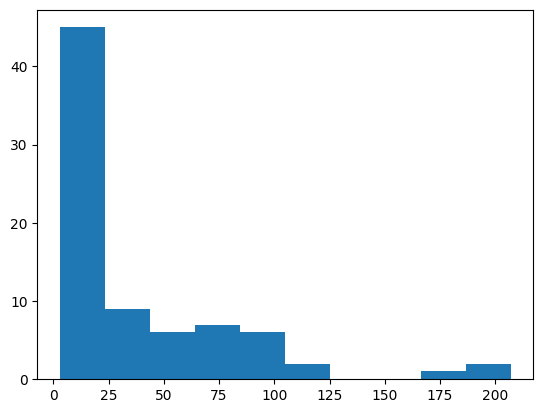

In [18]:
import matplotlib.pyplot as plt

stage_lengths = stage_edges[1:] - stage_edges[:-1]
plt.hist(stage_lengths)

In [21]:
for length_threshold in range(150, 60, -10):
    for num_edges in range(15, 7, -1):
        found = 0
        for i in range(num_edges + 1, len(stage_edges) - 1):
            edges = numpy.array(stage_edges[i-num_edges:i])
            lengths = edges[1:] - edges[:-1]
            if (lengths < length_threshold).sum() > len(edges) / 2:
                continue
            if edges[-1] - edges[0] > 2500:
                continue
            
            print(f"Found {num_edges} edges with threshold {length_threshold} with total length {edges[-1] - edges[0]}: {edges}")
            folder = f"sleep/{data_file[:-8]}-{found}"
            if folder == "sleep/SC4011E0-0":
                found += 1
                continue
            found += 1
            print(edges)
        if found:
            print('OK')

Found 8 edges with threshold 80 with total length 387: [1875 1992 2052 2070 2076 2157 2163 2262]
[1875 1992 2052 2070 2076 2157 2163 2262]
OK
Found 8 edges with threshold 70 with total length 387: [1875 1992 2052 2070 2076 2157 2163 2262]
[1875 1992 2052 2070 2076 2157 2163 2262]
Found 8 edges with threshold 70 with total length 489: [2367 2382 2460 2493 2547 2568 2652 2856]
[2367 2382 2460 2493 2547 2568 2652 2856]
OK


In [ ]:
mne.read_epochs("sleep/test/epochs.fif")

Reading d:\HSE\CourseProject\sleep\test\epochs.fif ...
Isotrak not found
    Found the data of interest:
        t =       0.00 ...    9990.00 ms
        0 CTF compensation matrices available
Not setting metadata
3048 matching events found
No baseline correction applied
0 projection items activated


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_5756\453755927.py:1: RuntimeWarning: This filename (sleep/test/epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  mne.read_epochs("sleep/test/epochs.fif")


<EpochsFIF | 3048 events (all good), 0 – 9.99 s (baseline off), ~162.8 MiB, data loaded,
 '1': 579
 '2': 270
 '3': 1251
 '4': 387
 '5': 561>